In [1]:
import seaborn as sns

df = sns.load_dataset("titanic")
FEATURES = ["age", "pclass", "sex", "fare", "sibsp", "parch"]
TARGET = "survived"

data = df[FEATURES + [TARGET]].copy()
data["age"] = data["age"].fillna(data["age"].median())
data["sex"] = (data["sex"] == "male").astype(int)

print(data["sex"].value_counts())
print(data.dtypes)

sex
1    577
0    314
Name: count, dtype: int64
age         float64
pclass        int64
sex           int64
fare        float64
sibsp         int64
parch         int64
survived      int64
dtype: object


In [2]:
from sklearn.model_selection import train_test_split

X = data[FEATURES].values
y = data[TARGET].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state = 42, stratify= y
)


In [3]:
from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_val = scaler.transform(X_val)



In [4]:
import torch
import torch.nn as nn


X_train = torch.tensor(X_train, dtype = torch.float32)
X_val = torch.tensor(X_val, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_val = torch.tensor(y_val, dtype = torch.float32)



In [5]:
class TitanicNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

torch.manual_seed(42)
model = TitanicNet(X_train.shape[1])
print(model)
print(f"параметрів ", sum(p.numel() for p in model.parameters()))


TitanicNet(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)
параметрів  769


In [6]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

for epoch in range(300):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train)
    assert logits.shape == y_train.shape
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 30 == 0:
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val)
            val_acc = ((val_logits > 0).float() == y_val).float().mean()
        print(f"epoch: {epoch:3d} train: {loss.item():.4f} "
              f"val: {val_loss.item():.4f} acc = {val_acc.item():.3f}")



epoch:   0 train: 0.6185 val: 0.6484 acc = 0.654
epoch:  30 train: 0.5875 val: 0.6395 acc = 0.642
epoch:  60 train: 0.5688 val: 0.6302 acc = 0.648
epoch:  90 train: 0.5441 val: 0.6052 acc = 0.704
epoch: 120 train: 0.5106 val: 0.5692 acc = 0.709
epoch: 150 train: 0.4715 val: 0.5266 acc = 0.760
epoch: 180 train: 0.4412 val: 0.4945 acc = 0.793
epoch: 210 train: 0.4262 val: 0.4788 acc = 0.810
epoch: 240 train: 0.4167 val: 0.4721 acc = 0.804
epoch: 270 train: 0.4101 val: 0.4702 acc = 0.804


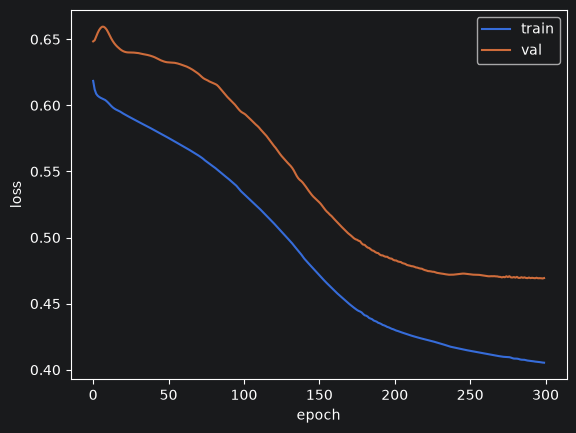

In [7]:
train_losses, val_losses = [ ], [ ]
torch.manual_seed(42)
model = TitanicNet(X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

for epoch in range(300):
    model.train()
    optimizer.zero_grad()
    loss = criterion(model(X_train), y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val), y_val)
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

import matplotlib.pyplot as plt
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


lr = LogisticRegression(max_iter= 1000).fit(X_train.numpy(), y_train.numpy())
rf = RandomForestClassifier(n_estimators = 200, random_state = 42).fit(X_train.numpy(), y_train.numpy())

model.eval()
with torch.no_grad():
    nn_acc = ((model(X_val) > 0).float() == y_val).float().mean().item()

print(f"LogisticRegression: {accuracy_score(y_val, lr.predict(X_val.numpy())):.3f}, class_report: {classification_report(y_val, lr.predict(X_val.numpy()))}")
print(f"RandomForest:       {accuracy_score(y_val, rf.predict(X_val.numpy())):.3f}, class_report: {classification_report(y_val, rf.predict(X_val.numpy()))}")
print(f"Нейромережа:        {nn_acc:.3f}")

LogisticRegression: 0.804, class_report:               precision    recall  f1-score   support

         0.0       0.83      0.86      0.84       110
         1.0       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

RandomForest:       0.810, class_report:               precision    recall  f1-score   support

         0.0       0.83      0.86      0.85       110
         1.0       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

Нейромережа:        0.804


In [10]:
import numpy as np
def run(X_tr, X_v, seeds=10):
    accs = []
    for seed in range(seeds):
        torch.manual_seed(seed)
        m = TitanicNet(X_tr.shape[1])
        opt = torch.optim.SGD(m.parameters(), lr=0.01)
        for _ in range(300):
            m.train(); opt.zero_grad()
            loss = criterion(m(X_tr), y_train)
            loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            accs.append(((m(X_v) > 0).float() == y_val).float().mean().item())
    return np.mean(accs), np.std(accs)
print(run(X_train, X_val))

(np.float64(0.6575419068336487), np.float64(0.01199492133084887))


In [11]:
import numpy as np, torch, torch.nn as nn, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- дані ---
df = sns.load_dataset("titanic")
FEATURES = ["age", "pclass", "sex", "fare", "sibsp", "parch"]
data = df[FEATURES + ["survived"]].copy()
data["age"] = data["age"].fillna(data["age"].median())
data["sex"] = (data["sex"] == "male").astype(int)

Xtr_raw, Xv_raw, ytr, yv = train_test_split(
    data[FEATURES].values, data["survived"].values,
    test_size=0.2, random_state=42, stratify=data["survived"].values
)

sc = StandardScaler()
Xtr_std, Xv_std = sc.fit_transform(Xtr_raw), sc.transform(Xv_raw)

t = lambda a: torch.tensor(a, dtype=torch.float32)
Xtr_raw, Xv_raw, Xtr_std, Xv_std = map(t, [Xtr_raw, Xv_raw, Xtr_std, Xv_std])
ytr, yv = t(ytr), t(yv)

# --- модель і прогін ---
class Net(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n,32), nn.ReLU(),
                                 nn.Linear(32,16), nn.ReLU(), nn.Linear(16,1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

criterion = nn.BCEWithLogitsLoss()

def run(Xtr, Xv, opt_cls, lr, epochs=300, seeds=10):
    accs = []
    for s in range(seeds):
        torch.manual_seed(s)
        m = Net(Xtr.shape[1])
        opt = opt_cls(m.parameters(), lr=lr)
        for _ in range(epochs):
            m.train(); opt.zero_grad()
            criterion(m(Xtr), ytr).backward(); opt.step()
        m.eval()
        with torch.no_grad():
            accs.append(((m(Xv) > 0).float() == yv).float().mean().item())
    return np.mean(accs), np.std(accs)

# --- таблиця ---
for name, X, Xv_, opt, lr in [
    ("Adam + std",      Xtr_std, Xv_std, torch.optim.Adam, 1e-3),
    ("Adam, no std",    Xtr_raw, Xv_raw, torch.optim.Adam, 1e-3),
    ("SGD + std",       Xtr_std, Xv_std, torch.optim.SGD,  0.01),
    ("SGD + std lr=.1", Xtr_std, Xv_std, torch.optim.SGD,  0.1),
    ("SGD, no std",     Xtr_raw, Xv_raw, torch.optim.SGD,  0.01),
]:
    mean, std = run(X, Xv_, opt, lr)
    print(f"{name:18s} {mean:.3f} ± {std:.3f}")

Adam + std         0.801 ± 0.007
Adam, no std       0.733 ± 0.035
SGD + std          0.668 ± 0.041
SGD + std lr=.1    0.818 ± 0.009
SGD, no std        0.658 ± 0.012
